# Case Study Assessment — NYC Airbnb Data Preprocessing
### Student Name:
### Date:

This notebook is your submission template. Fill in each section — do not delete the headers. Use markdown cells for your written justifications, right next to the code that supports them.

In [4]:
import pandas as pd
url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/AB_NYC_2019.csv"
df = pd.read_csv(url)
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


---
## Part 1 — Data Understanding & Quality Audit

In [5]:
df.tail()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2
48894,36487245,Trendy duplex in the very heart of Hell's Kitchen,68119814,Christophe,Manhattan,Hell's Kitchen,40.76404,-73.98933,Private room,90,7,0,NaN,NaN,1,23


In [6]:
# TODO: shape, dtypes, missing value summary
df.shape


(48895, 16)

In [7]:
## dtypes
df.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,int64


In [8]:
##info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [9]:
## missing values

df.isna().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [10]:
# TODO: check for values that are technically present but don't make real-world sense
# describe
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [11]:
# TODO: duplicate check
df.duplicated().sum()

np.int64(0)

**Written notes — what did you find, and what looks suspicious?**
1. i found that the dataset cantain numerical and categorical colunms. some missing values. i also checked the dataset of dupicate records.
2. suspicious....>
Zero values in price colunms and extrimely high values in minimum_nights.


---
## Part 2 — Missing Value Diagnosis & Treatment

In [12]:
# TODO: investigate missingness pattern(s) across columns
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [13]:
df['last_review'].isna().sum()

np.int64(10052)

In [14]:
df['reviews_per_month'].isna().sum()

np.int64(10052)

**Written justification — MCAR / MAR / MNAR classification per column, and your reasoning:**
_Number of missing value in both columns are same its because there was no reviews and hence no last review date. So i.m going to drop the column last_review because more than 20% are missing. Missing value in reviews_per_month are gonna be replaced by 0_

In [15]:
# TODO: apply your chosen treatment(s)
df=df.drop(['last_review',"reviews_per_month"],axis=1)

In [16]:
## i removed not importend colunms

df=df.drop(['id',"name",'host_name'],axis=1)

In [17]:
df.head()

,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
0,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,6,365
1,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2,355
2,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,1,365
3,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,1,194
4,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,1,0


**Written justification — why this treatment for each column, and what you'd risk with `dropna()` instead:**
1._I could keep the columns and give an imaginary date but that could influence model too much as its over 20% so I'd rather risk with dropping the column. But this method can cause lose in current popularity and booking recency in the data._

---
## Part 3 — Outlier Detection & Treatment

In [24]:
df.columns

Index(['host_id', 'neighbourhood_group', 'neighbourhood', 'latitude',
       'longitude', 'room_type', 'price', 'minimum_nights',
       'number_of_reviews', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

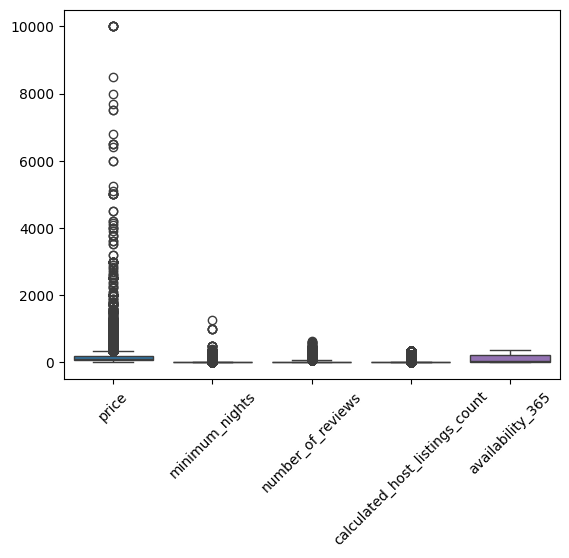

In [26]:
# TODO: detect outliers in at least two numeric columns
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(df[['price', 'minimum_nights', 'number_of_reviews',
       'calculated_host_listings_count', 'availability_365']])
plt.xticks(rotation=45)
plt.show()

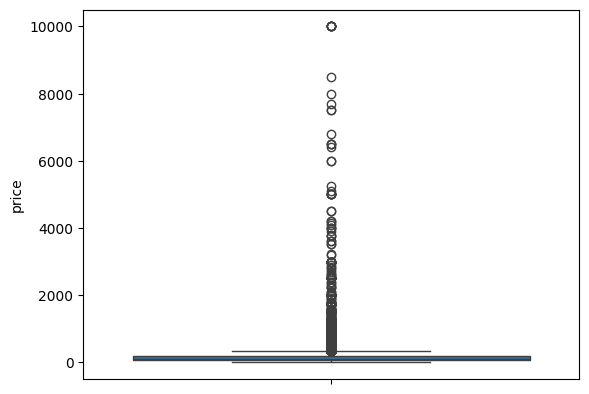

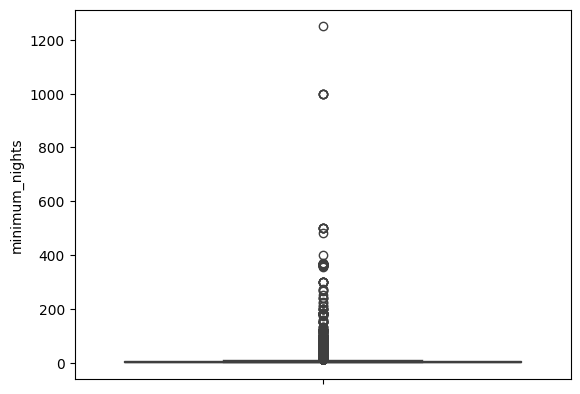

In [27]:
# i'm going to handle outliers in price and minimum_nights others are not that far in the plot and they seem like possible values
sns.boxplot(df['price'])
plt.show()
sns.boxplot(df['minimum_nights'])
plt.show()

**Written justification — for each outlier group, is it an error or a genuine listing? What evidence supports your call?**

_in case of price 0 is definitely an error and 10000 s a huge value so i'm going  to cap each values not to the lower limit and upper limit but minimum 30 and maximum 2000 dollars.As for minimum nights i'm going to cap the outliers to lower limit and upper limit._

In [28]:
# TODO: apply treatment consistent with your judgment above
# PRICE
df.loc[df['price']<30,'price']=30
df.loc[df['price']>2000,'price']=2000

#minimum_nights
q1 = df['minimum_nights'].quantile(0.25)
q3 = df['minimum_nights'].quantile(0.75)

iqr = q3 - q1

up_lim = q3 + (1.5 * iqr)
low_lim = q1 - (1.5 * iqr)

df.loc[df['minimum_nights']<low_lim,'minimum_nights']=low_lim
df.loc[df['minimum_nights']>up_lim,'minimum_nights']=up_lim

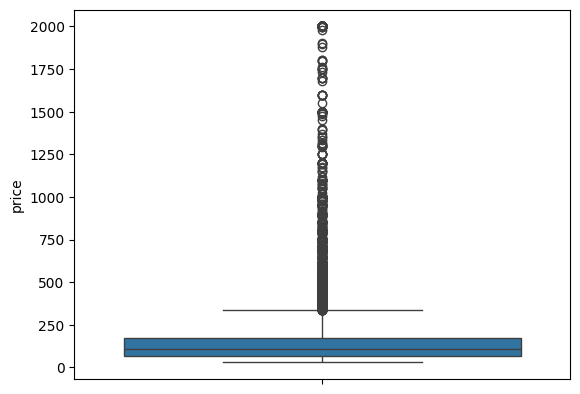

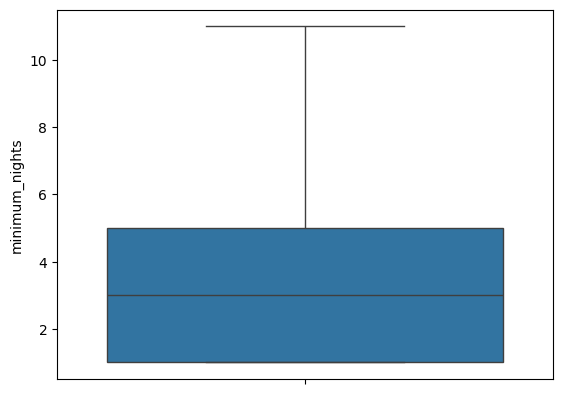

In [29]:
sns.boxplot(df['price'])
plt.show()
sns.boxplot(df['minimum_nights'])
plt.show()

---
## Part 4 — Feature Engineering & Encoding

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   host_id                         48895 non-null  int64  
 1   neighbourhood_group             48895 non-null  object 
 2   neighbourhood                   48895 non-null  object 
 3   latitude                        48895 non-null  float64
 4   longitude                       48895 non-null  float64
 5   room_type                       48895 non-null  object 
 6   price                           48895 non-null  int64  
 7   minimum_nights                  48895 non-null  int64  
 8   number_of_reviews               48895 non-null  int64  
 9   calculated_host_listings_count  48895 non-null  int64  
 10  availability_365                48895 non-null  int64  
dtypes: float64(2), int64(6), object(3)
memory usage: 4.1+ MB


In [31]:
# TODO: encode categorical columns appropriately
df['neighbourhood'].unique()

array(['Kensington', 'Midtown', 'Harlem', 'Clinton Hill', 'East Harlem',
       'Murray Hill', 'Bedford-Stuyvesant', "Hell's Kitchen",
       'Upper West Side', 'Chinatown', 'South Slope', 'West Village',
       'Williamsburg', 'Fort Greene', 'Chelsea', 'Crown Heights',
       'Park Slope', 'Windsor Terrace', 'Inwood', 'East Village',
       'Greenpoint', 'Bushwick', 'Flatbush', 'Lower East Side',
       'Prospect-Lefferts Gardens', 'Long Island City', 'Kips Bay',
       'SoHo', 'Upper East Side', 'Prospect Heights',
       'Washington Heights', 'Woodside', 'Brooklyn Heights',
       'Carroll Gardens', 'Gowanus', 'Flatlands', 'Cobble Hill',
       'Flushing', 'Boerum Hill', 'Sunnyside', 'DUMBO', 'St. George',
       'Highbridge', 'Financial District', 'Ridgewood',
       'Morningside Heights', 'Jamaica', 'Middle Village', 'NoHo',
       'Ditmars Steinway', 'Flatiron District', 'Roosevelt Island',
       'Greenwich Village', 'Little Italy', 'East Flatbush',
       'Tompkinsville', 'Asto

In [32]:
frequency = df['neighbourhood'].value_counts()

df['neighbourhood'] = df['neighbourhood'].map(frequency)
print(df['neighbourhood'])

0         175
1        1545
2        2658
3         572
4        1117
         ... 
48890    3714
48891    2465
48892    2658
48893    1958
48894    1958
Name: neighbourhood, Length: 48895, dtype: int64


In [33]:
df.head()

,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
0,2787,Brooklyn,175,40.64749,-73.97237,Private room,149,1,9,6,365
1,2845,Manhattan,1545,40.75362,-73.98377,Entire home/apt,225,1,45,2,355
2,4632,Manhattan,2658,40.80902,-73.94190,Private room,150,3,0,1,365
3,4869,Brooklyn,572,40.68514,-73.95976,Entire home/apt,89,1,270,1,194
4,7192,Manhattan,1117,40.79851,-73.94399,Entire home/apt,80,10,9,1,0


In [34]:
df['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

In [35]:
# TODO: engineer at least two new features
from sklearn.preprocessing import OrdinalEncoder
encoder= OrdinalEncoder(
    categories=[['Shared room', 'Private room', 'Entire home/apt']]
)
df['room_type']=encoder.fit_transform(df[['room_type']])

In [36]:
df['neighbourhood_group'].unique()

array(['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx'],
      dtype=object)

In [37]:
df=pd.get_dummies(df,prefix='group',dtype='int',drop_first=True)

In [38]:

df.head()

,host_id,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,group_Brooklyn,group_Manhattan,group_Queens,group_Staten Island
0,2787,175,40.64749,-73.97237,1.0,149,1,9,6,365,1,0,0,0
1,2845,1545,40.75362,-73.98377,2.0,225,1,45,2,355,0,1,0,0
2,4632,2658,40.80902,-73.94190,1.0,150,3,0,1,365,0,1,0,0
3,4869,572,40.68514,-73.95976,2.0,89,1,270,1,194,1,0,0,0
4,7192,1117,40.79851,-73.94399,2.0,80,10,9,1,0,0,1,0,0


In [39]:
df=df.drop(['latitude','longitude'],axis =1)

**Written justification — why these features, and which column(s) should NOT be used to predict price, and why:**

_First 4 columns are dropped they we id,name,host_id,host_name. They don't need to be present for prediction. Also latitude and longitude doesn't provide any pupose when it comes to ml modelling in this case. other  object column were handled neighbourhood is handled by frequency encoder, room_type has ordinal data so ordinal encoding is done and for neighbourhood_group OneHotEncoding is done_

---
## Part 5 — Build a Reusable Preprocessing Pipeline

In [40]:
## import libraries

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [22]:
# TODO: train/test split (before fitting anything)


In [41]:
# TODO: build Pipeline combining your cleaning, imputation, encoding, scaling steps
url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/AB_NYC_2019.csv"
df = pd.read_csv(url)
df.head()
# Missing value handling and removing Unnecessary columns
df=df.drop(['last_review','id','name','host_id','host_name','latitude','longitude'],axis=1)
df['reviews_per_month']=df['reviews_per_month'].fillna(0)

In [42]:
# Outlier Management
# PRICE
df.loc[df['price']<30,'price']=30
df.loc[df['price']>2000,'price']=2000

#minimum_nights
q1 = df['minimum_nights'].quantile(0.25)
q3 = df['minimum_nights'].quantile(0.75)

iqr = q3 - q1

up_lim = q3 + (1.5 * iqr)
low_lim = q1 - (1.5 * iqr)

df.loc[df['minimum_nights']<low_lim,'minimum_nights']=low_lim
df.loc[df['minimum_nights']>up_lim,'minimum_nights']=up_lim

In [44]:
# TODO: train/test split (before fitting anything)
#Separeate x,and y
y =df['price']
x = df.drop('price',axis=1)

# Train_test split
x_train,x_test,y_train,y_test =train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [43]:
#Encoding:
# neighbourhood - frequency encoding,
frequency = df['neighbourhood'].value_counts()
df['neighbourhood'] = df['neighbourhood'].map(frequency)
print(df['neighbourhood'])

0         175
1        1545
2        2658
3         572
4        1117
         ... 
48890    3714
48891    2465
48892    2658
48893    1958
48894    1958
Name: neighbourhood, Length: 48895, dtype: int64


In [45]:
numerical_columns = ['neighbourhood','minimum_nights','number_of_reviews','reviews_per_month','calculated_host_listings_count','availability_365']
nominal_columns = ['neighbourhood_group']
ordinal_columns = ['room_type']

In [46]:
numerical_pipeline = Pipeline([
    ('scalar',StandardScaler())
])

In [47]:
nominal_pipeline = Pipeline([
    ('encoder', OneHotEncoder(drop='first', sparse_output=False))
])

In [48]:
ordinal_pipeline = Pipeline([
    ('encoder',OrdinalEncoder(
        categories=[['Shared room', 'Private room', 'Entire home/apt']]
    ))
])

In [49]:
# Combine Pipelines
preprocessor = ColumnTransformer([
    ('numeric',numerical_pipeline,numerical_columns),
    ('nominal',nominal_pipeline,nominal_columns),
    ('ordinal', ordinal_pipeline, ordinal_columns)
])

In [50]:
# Fit and transform training data
x_train_preprocessed = preprocessor.fit_transform(x_train)
x_test_preprocessed = preprocessor.transform(x_test)

In [51]:
x_train.shape

(39116, 8)

---
## Part 6 — Written Reflection

1. _Dropping last_review must have effected on this process. But this method can cause loss in current popularity and booking recency in the data._
2. _If we do this on live data outlier handling, missing value detection and frequency encoding is what we would need to change._
3. _Because there was too many rows with missing value if i delete each rows it'll be too much of data loss._